In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sandbox.jordan8 import *

import json

In [2]:
device = setup_device()

torch.manual_seed(0)
np.random.seed(0)

# Training from scratch

In [3]:
model = JordanNet(encode_dim=32)

training_dimensions = [4, 12, 20, 28]
for d in training_dimensions:
    model.add_dimension(d)

training_dataset = generate_training_datasets(matrices_per_class=2000,
                                              dimensions=training_dimensions)

model = train_jordan_net(
    model,
    training_dataset,
    num_epochs=50, 
    batch_size=64,
    lr=1e-3,
    device=device,
    train_transformer=True,
    patience=3,
)

Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Generating class with d=12, max_block_size=1...Done.
Generating class with d=12, max_block_size=2...Done.
Generating class with d=12, max_block_size=3...Done.
Generating class with d=12, max_block_size=4...Done.
Generating class with d=12, max_block_size=5...Done.
Generating class with d=12, max_block_size=6...Done.
Generating class with d=12, max_block_size=7...Done.
Generating class with d=12, max_block_size=8...Done.
Generating class with d=12, max_block_size=9...Done.
Generating class with d=12, max_block_size=10...Done.
Generating class with d=12, max_block_size=11...Done.
Generating class with d=12, max_block_size=12...Done.
Generating class with d=20, max_block_size=1...Done.
Generating class with d=20, max_block_size=2...Done.
Generating class with d=20, max_block_size=3...

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Epoch [1/50] | Train Loss: 1.334991 | Val Loss: 1.912614
Epoch [2/50] | Train Loss: 1.070422 | Val Loss: 1.661939
Epoch [3/50] | Train Loss: 0.968647 | Val Loss: 1.348389
Epoch [4/50] | Train Loss: 0.868900 | Val Loss: 1.216867
Epoch [5/50] | Train Loss: 0.783137 | Val Loss: 1.040497
Epoch [6/50] | Train Loss: 0.713615 | Val Loss: 1.007173
Epoch [7/50] | Train Loss: 0.656682 | Val Loss: 0.899464
Epoch [8/50] | Train Loss: 0.609819 | Val Loss: 0.824644
Epoch [9/50] | Train Loss: 0.582139 | Val Loss: 0.979350
Epoch [10/50] | Train Loss: 0.548582 | Val Loss: 0.756621
Epoch [11/50] | Train Loss: 0.520038 | Val Loss: 0.694940
Epoch [12/50] | Train Loss: 0.491952 | Val Loss: 0.591611
Epoch [13/50] | Train Loss: 0.467351 | Val Loss: 0.540331
Epoch [14/50] | Train Loss: 0.440242 | Val Loss: 0.515156
Epoch [15/50] | Train Loss: 0.431102 | Val Loss: 0.496788
Epoch [16/50] | Train Loss: 0.400841 | Val Loss: 0.485879
Epoch [17/50] | Train Loss: 0.366165 | Val Loss: 0.420580
Epoch [18/50] | Train L

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:434: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename))


# Tests

In [3]:
def run_test(model, d, matrices_per_class=1000, mode="random", eps=None, eps_range=None):
    model.eval()

    training_dataset = generate_training_datasets(
        matrices_per_class=matrices_per_class,
        dimensions=[d],
        mode=mode,
        eps=eps,
        eps_range=eps_range,
        device="cpu",
    )
    matrices, labels, features, masks, dists = training_dataset[d]
    loader = DataLoader(TensorDataset(features, labels, masks, dists), batch_size=64, shuffle=False)

    predicted_classes = []
    true_classes = labels.cpu().tolist()
    kl_avg = 0.0

    for batch_features, batch_labels, batch_masks, batch_dists in loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        batch_masks = batch_masks.to(device)
        batch_dists = batch_dists.to(device)

        logits = model(d, batch_features, masks=batch_masks)
        loss = kl_loss(logits, batch_dists)

        preds = torch.argmax(logits, dim=-1)
        predicted_classes += preds.cpu().tolist()
        kl_avg += loss.item() * batch_features.size(0)

    kl_avg /= len(loader.dataset)
    # print(f"Test KL Loss: {kl_avg:.6f}")

    return true_classes, predicted_classes, kl_avg

def test_jordan_net(model, d, matrices_per_class=1000, filename=None):
    if filename is None:
        filename = f"sandbox/jordan8_results/results_{d}.json"

    results = []

    for eps in [0.0, 1e-6, 1e-4, 1e-2, 1e-1, 1]:
        print(f"Testing with eps={eps}")
        true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="random", eps=eps)
        results.append({
            "eps": eps,
            "true_classes": true_classes,
            "predicted_classes": predicted_classes,
            "kl_avg": kl_avg,
        })
    
    print(f"Testing mode 'ortho'")
    true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="ortho", eps=0.0)
    results.append({
        "eps": "ortho",
        "true_classes": true_classes,
        "predicted_classes": predicted_classes,
        "kl_avg": kl_avg,
    })
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)
    
def visualize_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f) 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, d+1)))
        disp.plot(cmap=plt.cm.Blues)
        title = f"{'eps='+str(eps) if eps != 'ortho' else 'ortho'}. KL Loss: {result['kl_avg']:.6f}, accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        plt.title(title)
        plt.show()
    
def print_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f)

    print(f"\nTest results for dimension {d}:") 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        title = f"\t{'eps='+f'{eps:<10}' if eps != 'ortho' else 'ortho     '}\t KL Loss: {result['kl_avg']:.6f},\t accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        print(title)

In [9]:
model = JordanNet(encode_dim=32)
training_dimensions = [4, 12, 20, 28]
for d in training_dimensions:
    model.add_dimension(d)
model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"))
model.to(device)
for d in training_dimensions:
    test_jordan_net(model, d, matrices_per_class=1000)

Testing with eps=0.0
Generating class with d=4, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_12516\678708035.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"

Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=1e-06
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.0001
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.01
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.1
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class wit

In [10]:
for d in training_dimensions:
    print_test_results(d, f"sandbox/jordan8_results/results_{d}.json")


Test results for dimension 4:
	eps=0.0       	 KL Loss: 0.093610,	 accuracy: 0.9988
	eps=1e-06     	 KL Loss: 0.025709,	 accuracy: 0.9988
	eps=0.0001    	 KL Loss: 0.440803,	 accuracy: 0.9970
	eps=0.01      	 KL Loss: 0.835919,	 accuracy: 0.8380
	eps=0.1       	 KL Loss: 1.851444,	 accuracy: 0.2833
	eps=1         	 KL Loss: 2.966569,	 accuracy: 0.2500
	ortho     	 KL Loss: 0.089238,	 accuracy: 1.0000

Test results for dimension 12:
	eps=0.0       	 KL Loss: 0.357017,	 accuracy: 0.8147
	eps=1e-06     	 KL Loss: 0.052149,	 accuracy: 0.9978
	eps=0.0001    	 KL Loss: 0.511641,	 accuracy: 0.9910
	eps=0.01      	 KL Loss: 1.127356,	 accuracy: 0.4364
	eps=0.1       	 KL Loss: 17.682765,	 accuracy: 0.0837
	eps=1         	 KL Loss: 4.793704,	 accuracy: 0.0831
	ortho     	 KL Loss: 0.384572,	 accuracy: 0.7903

Test results for dimension 20:
	eps=0.0       	 KL Loss: 0.514139,	 accuracy: 0.7551
	eps=1e-06     	 KL Loss: 0.087502,	 accuracy: 0.9792
	eps=0.0001    	 KL Loss: 0.162363,	 accuracy: 0

# Training + tests on additional dimensions

In [12]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 12, 20, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth", map_location="cpu"))
model.to(device)

new_dimensions = [35]

for d in new_dimensions:
    model.add_dimension(d)
    training_dataset = generate_training_datasets(matrices_per_class=500,
                                                dimensions=[d])
    model = train_jordan_net(
        model,
        training_dataset,
        num_epochs=50,
        batch_size=64,
        lr=1e-3,
        device=device,
        train_transformer=False)

Generating class with d=35, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_17876\875241146.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"

Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating class with d=35, max_block_size=19...Done.
Generating class with d=35, ma

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:434: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename))


In [5]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 12, 20, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

new_dimensions = [35]

for d in new_dimensions:
    model.add_dimension(d)


model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.to(device)

C:\Users\micha\AppData\Local\Temp\ipykernel_14940\1033126638.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_mo

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (12): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=144, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (20): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=400, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, 

In [7]:
for d in new_dimensions:
    test_jordan_net(model, d, matrices_per_class=500)

Testing with eps=0.0
Generating class with d=35, max_block_size=1...Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating class

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Testing with eps=1e-06
Generating class with d=35, max_block_size=1...Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating cla

In [5]:
for d in [35]:
    print_test_results(d, f"sandbox/jordan8_results/results_{d}.json")


Test results for dimension 35:
	eps=0.0       	 KL Loss: 1.174656,	 accuracy: 0.5473
	eps=1e-06     	 KL Loss: 0.177876,	 accuracy: 0.9840
	eps=0.0001    	 KL Loss: 0.332852,	 accuracy: 0.8891
	eps=0.01      	 KL Loss: 2.908995,	 accuracy: 0.1571
	eps=0.1       	 KL Loss: 13.732401,	 accuracy: 0.0286
	eps=1         	 KL Loss: 1.611621,	 accuracy: 0.0286
	ortho     	 KL Loss: 5.907729,	 accuracy: 0.0804


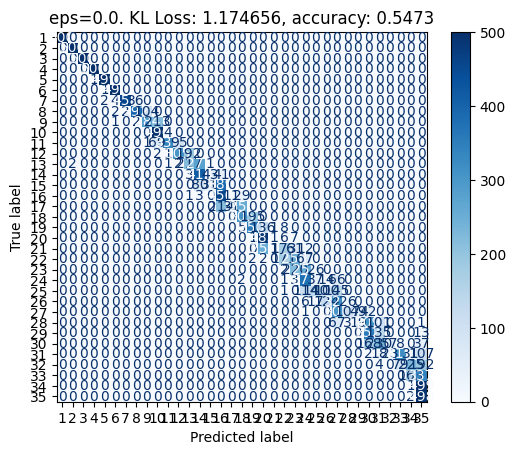

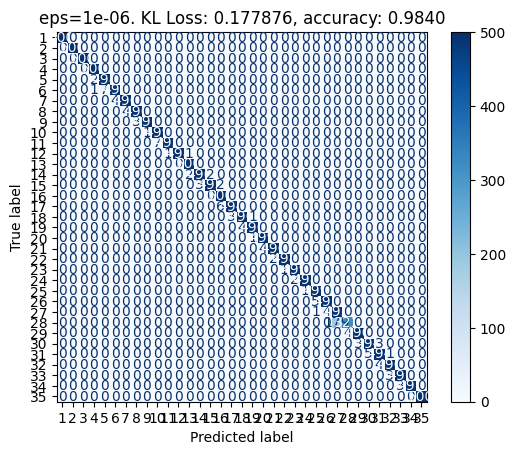

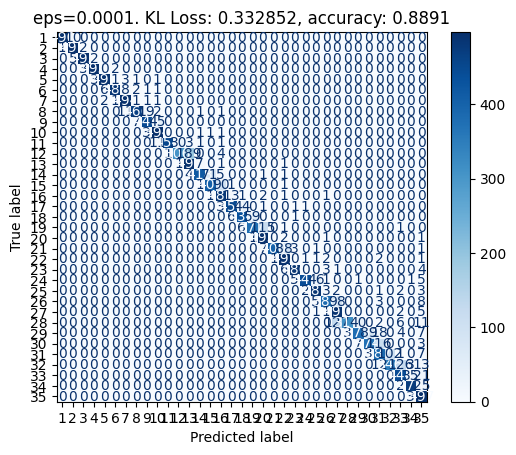

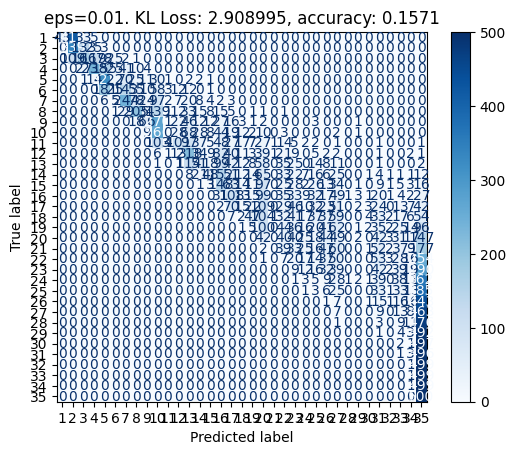

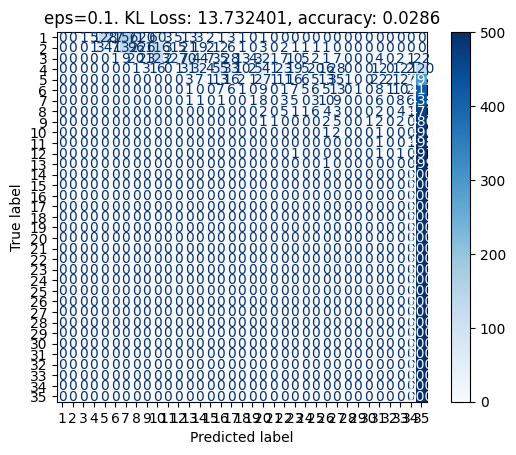

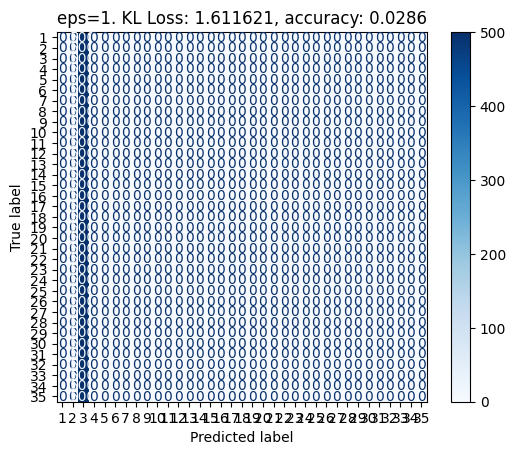

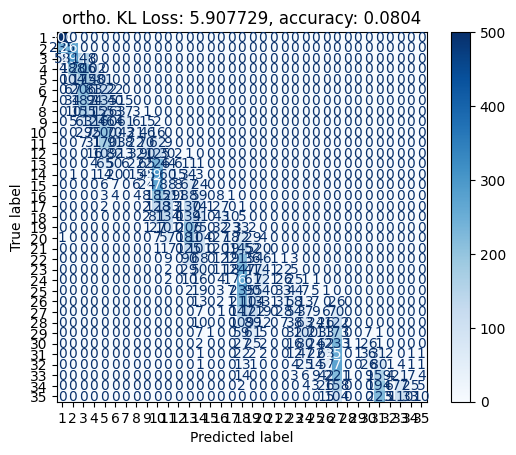

In [6]:
visualize_test_results(35, f"sandbox/jordan8_results/results_35.json")

# Test results comparison

In [7]:
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_model_results(folder_path, epsilons, d_train):
    """
    Parses result JSONs and plots KL-loss and Accuracy across dimensions d.
    """
    # Data structure: { epsilon: { d_value: {'kl': [], 'acc': []} } }
    data = defaultdict(lambda: defaultdict(lambda: {'kl': None, 'acc': None}))
    
    # 1. Data Extraction
    for filename in os.listdir(folder_path):
        if filename.startswith("results_") and filename.endswith(".json"):
            # Extract d from filename (e.g., results_10.json -> 10)
            try:
                d = int(filename.split('_')[1].split('.')[0])
            except ValueError:
                continue
                
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as f:
                results = json.load(f)
            
            for entry in results:
                curr_eps = entry.get("eps")
                
                # Only process if this epsilon is in our target list
                if curr_eps in epsilons:
                    # Calculate Accuracy
                    preds = entry.get("predicted_classes", [])
                    trues = entry.get("true_classes", [])
                    acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
                    
                    # Store values
                    data[curr_eps][d]['kl'] = entry.get("kl_avg")
                    data[curr_eps][d]['acc'] = acc

    # 2. Preparation for Plotting
    # Sort epsilons for consistent legend order
    sorted_eps = sorted(epsilons, key=lambda x: (str(type(x)), x))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    for eps in sorted_eps:
        # Sort by d to ensure lines connect correctly
        sorted_ds = sorted(data[eps].keys())
        kl_vals = [data[eps][d]['kl'] for d in sorted_ds]
        acc_vals = [data[eps][d]['acc'] for d in sorted_ds]
        
        label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
        
        ax1.plot(sorted_ds, kl_vals, marker='o', label=label)
        ax2.plot(sorted_ds, acc_vals, marker='s', label=label)

    # 3. Mark "Base Training Dimensions"
    # We'll use a vertical span (shaded area) or lines to highlight training d
    for ax in [ax1, ax2]:
        for i, d_val in enumerate(d_train):
            # Adding a vertical dashed line for each training dimension
            ax.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5, 
                       label="Train Dim" if i == 0 else "")
            # Adding a subtle highlight/text
            ax.text(d_val, ax.get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

    # Formatting
    ax1.set_title("Average KL-Loss vs Dimension ($d$)")
    ax1.set_xlabel("Dimension ($d$)")
    ax1.set_ylabel("KL Loss")
    ax1.legend()
    ax1.grid(True, which='both', linestyle=':', alpha=0.5)

    ax2.set_title("Accuracy vs Dimension ($d$)")
    ax2.set_xlabel("Dimension ($d$)")
    ax2.set_ylabel("Accuracy Score")
    ax2.legend()
    ax2.grid(True, which='both', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Example Usage:
# plot_model_results('./results_folder', [0.1, 0.5, 'ortho'], [10, 50])

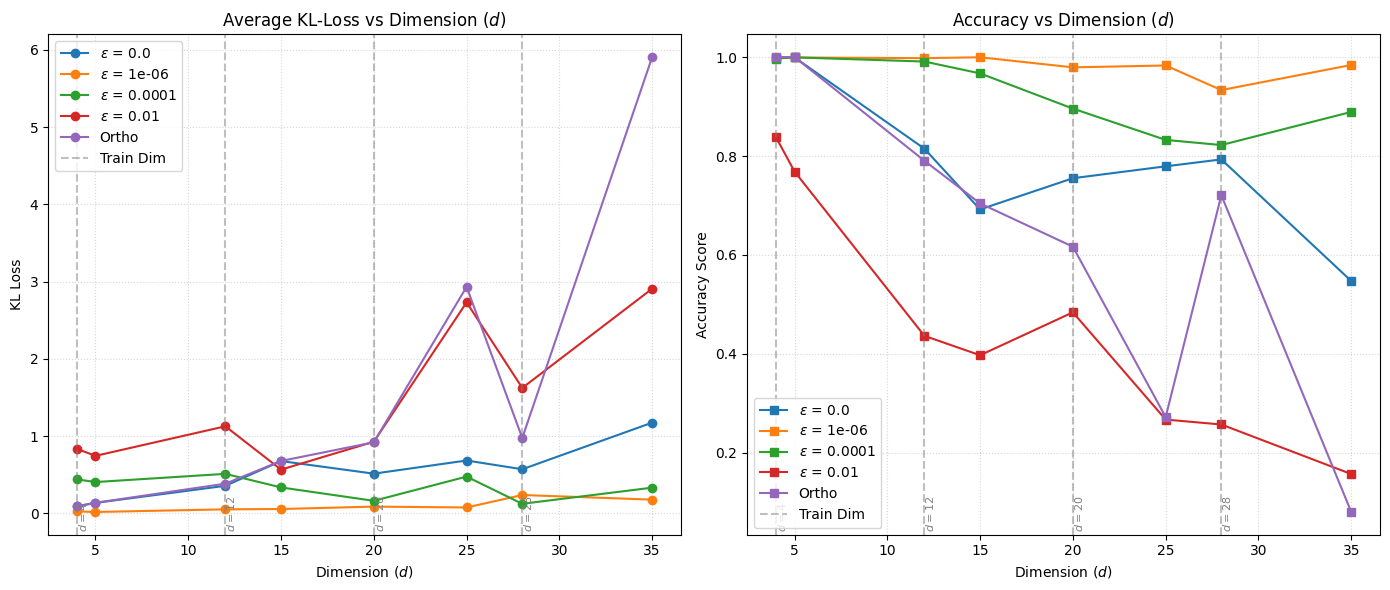

In [ ]:
plot_model_results('./sandbox/jordan8_results', [0.0, 1e-6, 1e-4, 1e-2, 'ortho'], pretrained_dimensions)

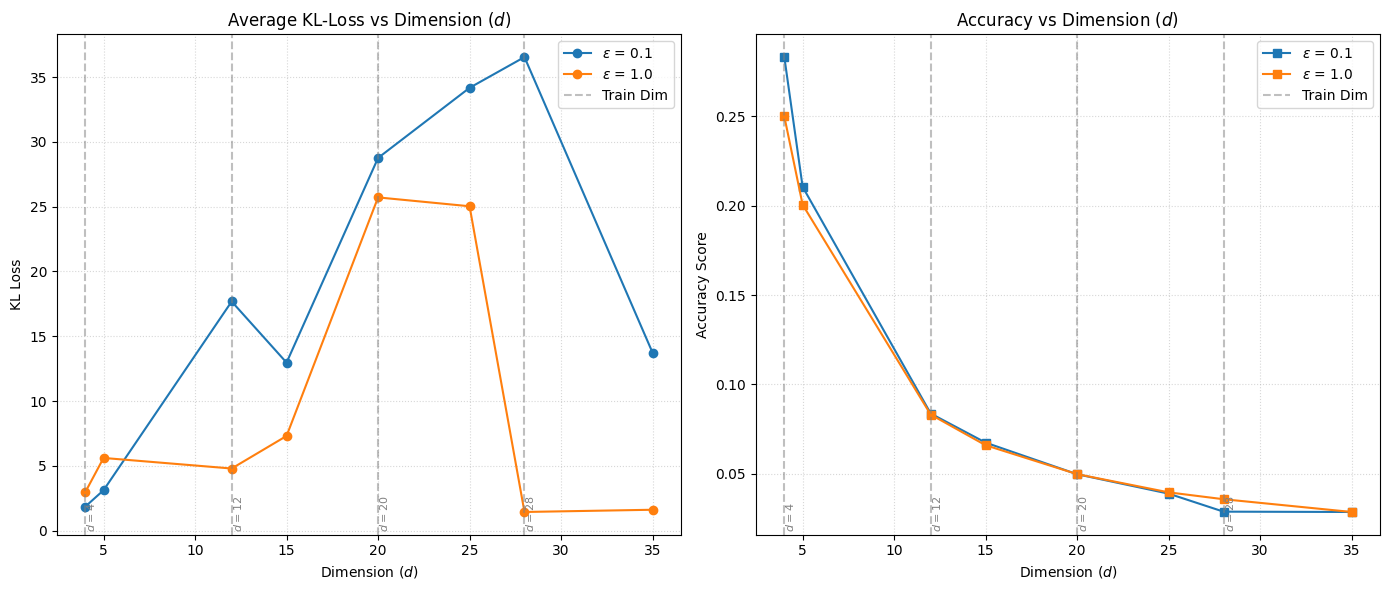

In [ ]:
plot_model_results('./sandbox/jordan8_results', [0.1, 1.0], pretrained_dimensions)